Dla ustalonej długości danych 𝑁 = 100 i dla 𝜃0 = 1 i 𝜃1 ∈
{−0,9; −0,5; −0,1; 0; 0,1; 0,5; 0,9} oraz 𝜎
2 = 1 przeprowadzić następującą symulację:
1. Wygenerować 𝑁 wartości modelu MA(1): 𝑋𝑡 = 𝜃0 + 𝜃1𝜀𝑡−1 + 𝜀𝑡
, 𝜀𝑡~𝑖𝑖𝑑(0, 𝜎
2
).
2. Na podstawie wygenerowanych danych oszacować parametry modelu MA(1).
3. Zapamiętać wartości oszacowań parametrów modelu MA(1) (tzn. 𝜃0 i 𝜃1), ich
odchyleń standardowych i statystyki do testów czy te parametry są równe
wartościom teoretycznym.
4. Kroki 1-3 powtórzyć 1000 razy.
Obliczyć statystyki opisowe rozkładów uzyskanych wartości. Przedstawić graficznie ich
rozkłady. Zbadać normalność tych rozkładów.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
from itertools import product

In [3]:
N = (20, 100, 500)
theta0 = 1
theta1 = (-0.9, -0.5, -0.1, 0, 0.1, 0.5, 0.9)
sigma2 = 1
num_simulations = 1000

summaries = dict()

In [4]:


def generate_ma1(N, theta0, theta1, sigma):
    """
    Generate N values of MA(1) model: X_t = theta0 + theta1 * epsilon_{t-1} + epsilon_t
    where epsilon_t ~ iid(0, sigma^2)
    """
    # Generate white noise epsilon_t
    epsilon = np.random.normal(0, sigma, N + 1)  # N+1 to account for epsilon_{-1}

    # Initialize the series
    X = np.zeros(N)

    # Generate MA(1) series
    for t in range(N):
        X[t] = theta0 + theta1 * epsilon[t] + epsilon[t + 1]

    return X

# Test the function with one set of parameters
np.random.seed(123)  # For reproducibility

In [5]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters found.")


def test(theta1_value, sample_size, simulations=num_simulations):
	records = []

	for _ in range(simulations):
		X_sample = generate_ma1(sample_size, theta0, theta1_value, sigma2)

		model = ARIMA(X_sample, order=(0, 0, 1))
		model_fit = model.fit()

		t_theta0 = (model_fit.params[0] - theta0) / model_fit.bse[0]
		t_theta1 = (model_fit.params[1] - theta1_value) / model_fit.bse[1]

		params = {
				"theta0": theta0,
				"theta1": theta1_value,
				"N": sample_size,
				"est_theta0": model_fit.params[0],
				"est_theta1": model_fit.params[1],
				"theta0_std_err": model_fit.bse[0],
				"theta1_std_err": model_fit.bse[1],
				"t_theta0": t_theta0,
				"t_theta1": t_theta1,
		}

		records.append(params)

	return pd.DataFrame.from_records(records)



total_runs = len(theta1) * len(N)

for idx, (theta1_value, sample_size) in enumerate(product(theta1, N), start=1):
    print(
        f"Running simulation for theta1={theta1_value}, N={sample_size} ({idx}/{total_runs})"
    )
    summaries[(theta1_value, sample_size)] = test(theta1_value, sample_size)

Running simulation for theta1=-0.9, N=20 (1/21)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Running simulation for theta1=-0.9, N=100 (2/21)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Running simulation for theta1=-0.9, N=500 (3/21)


...

Running simulation for theta1=0, N=100 (11/21)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Running simulation for theta1=0, N=500 (12/21)
Running simulation for theta1=0.1, N=20 (13/21)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Running simulation for theta1=0.1, N=100 (14/21)
Running simulation for theta1=0.1, N=500 (15/21)
Running simulation for theta1=0.5, N=20 (16/21)
Running simulation for theta1=0.5, N=100 (17/21)
Running simulation for theta1=0.5, N=500 (18/21)
Running simulation for theta1=0.9, N=20 (19/21)
Running simulation for theta1=0.9, N=100 (20/21)
Running simulation for theta1=0.9, N=500 (21/21)


In [6]:
for (theta1_value, sample_size), df in summaries.items():
    print(f"Summary for theta1 = {theta1_value}, N = {sample_size}")
    print(df.describe().T)
    print("\n")

Summary for theta1 = -0.9, N = 20
                 count        mean           std        min        25%  \
theta0          1000.0    1.000000  0.000000e+00   1.000000   1.000000   
theta1          1000.0   -0.900000  1.510659e-14  -0.900000  -0.900000   
N               1000.0   20.000000  0.000000e+00  20.000000  20.000000   
est_theta0      1000.0    1.001603  4.342645e-02   0.843280   0.971609   
est_theta1      1000.0   -0.949214  1.804514e-01  -0.999977  -0.999916   
theta0_std_err  1000.0    0.056079  3.984580e-02   0.018861   0.038176   
theta1_std_err  1000.0  238.880809  2.515134e+02   0.162115  50.229894   
t_theta0        1000.0    0.047281  9.459074e-01  -3.023066  -0.525543   
t_theta1        1000.0    0.157199  6.015759e-01  -0.041496  -0.001445   

                       50%         75%          max  
theta0            1.000000    1.000000     1.000000  
theta1           -0.900000   -0.900000    -0.900000  
N                20.000000   20.000000    20.000000  
est_theta

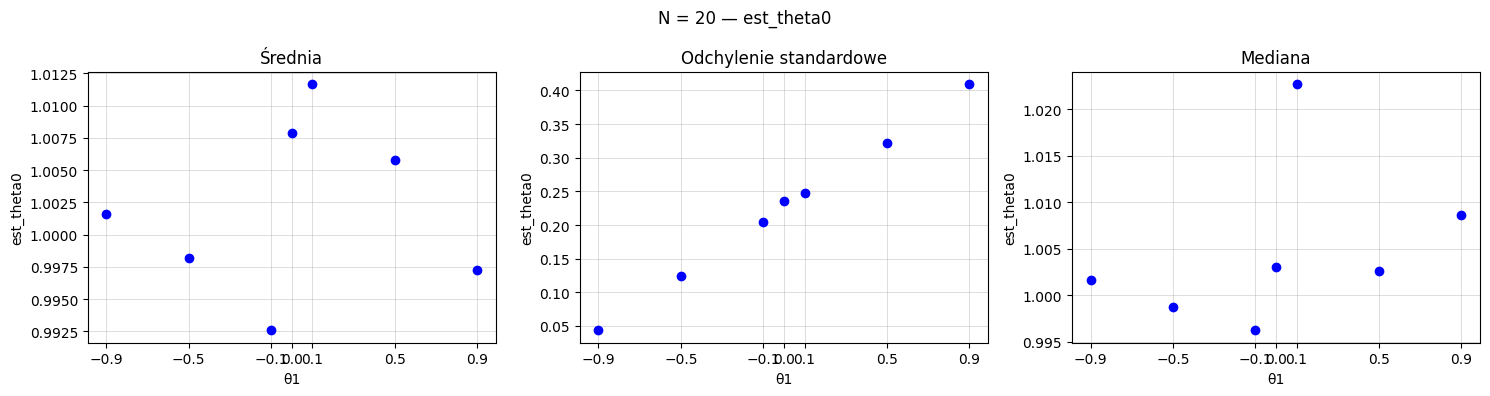

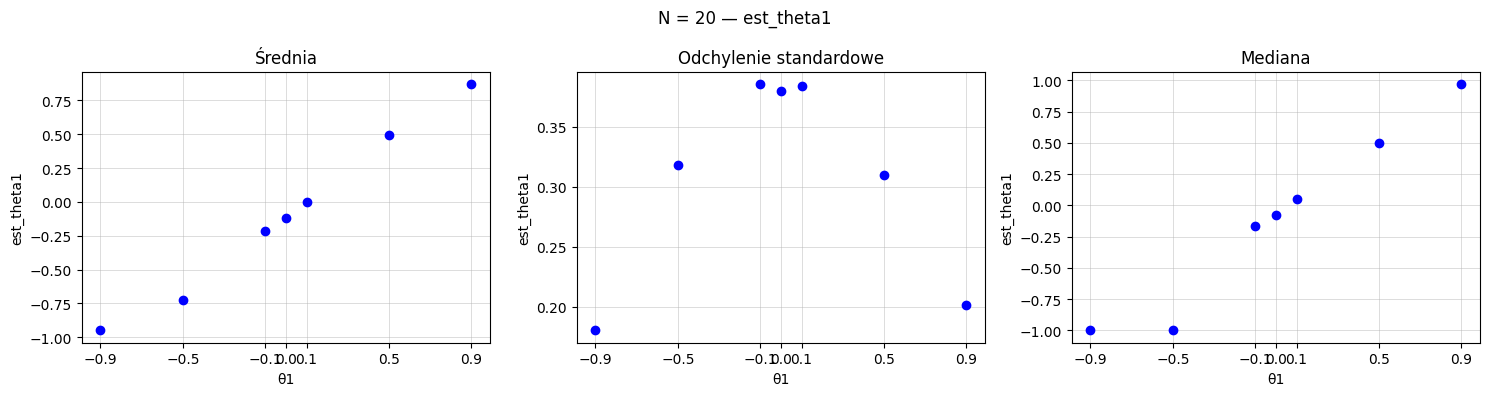

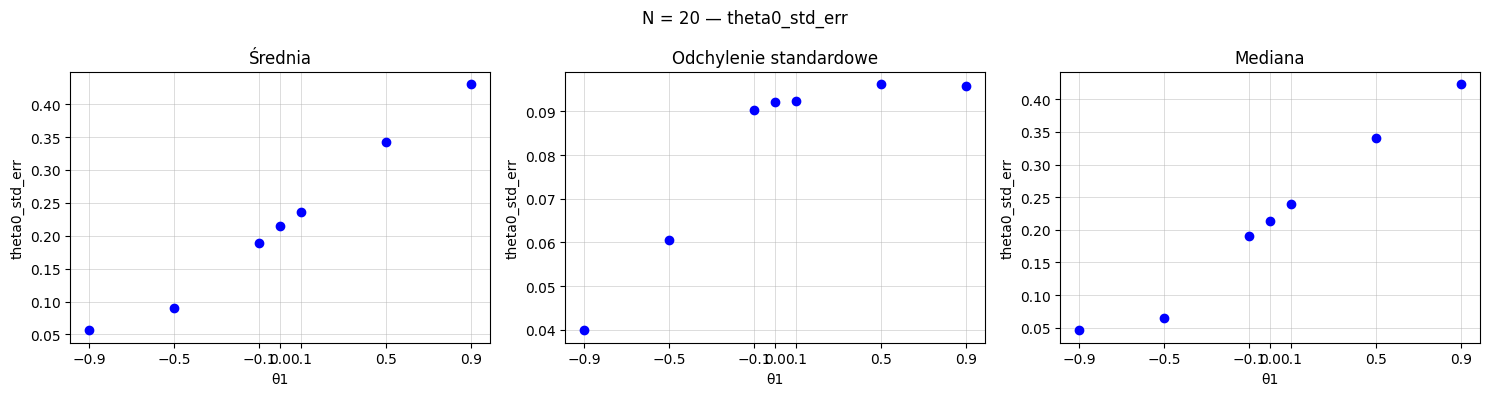

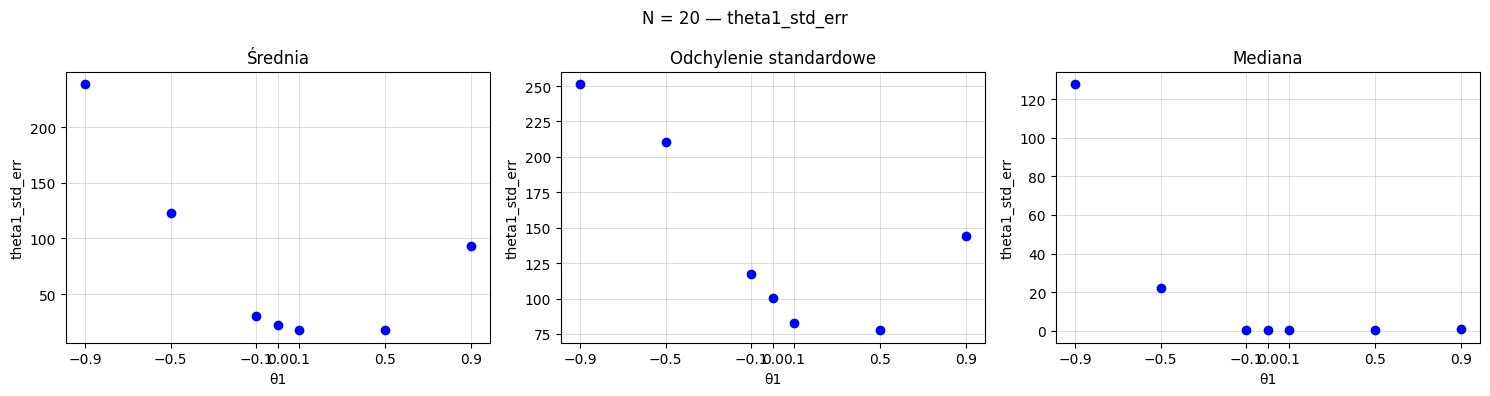

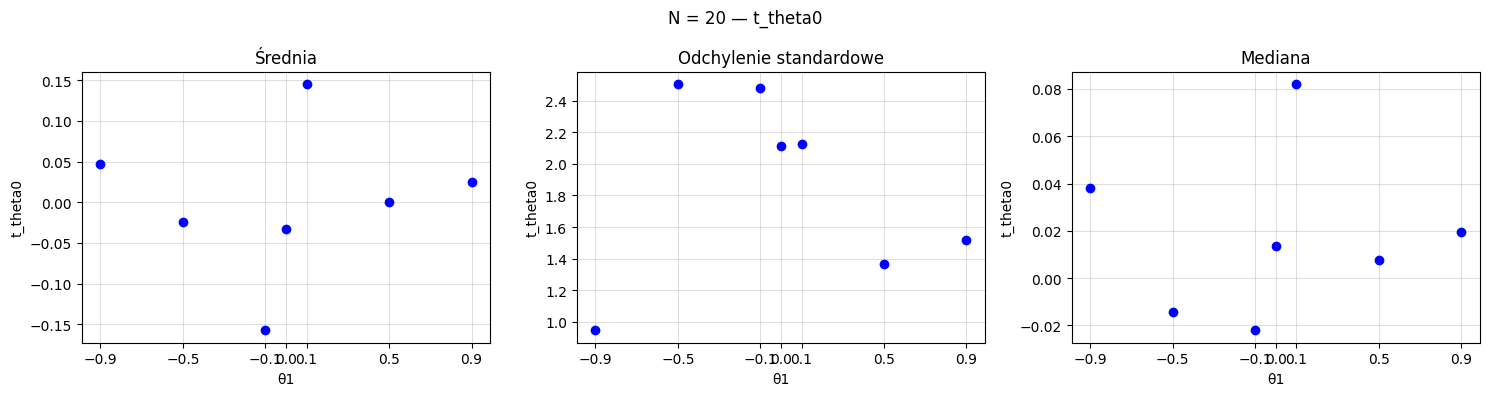

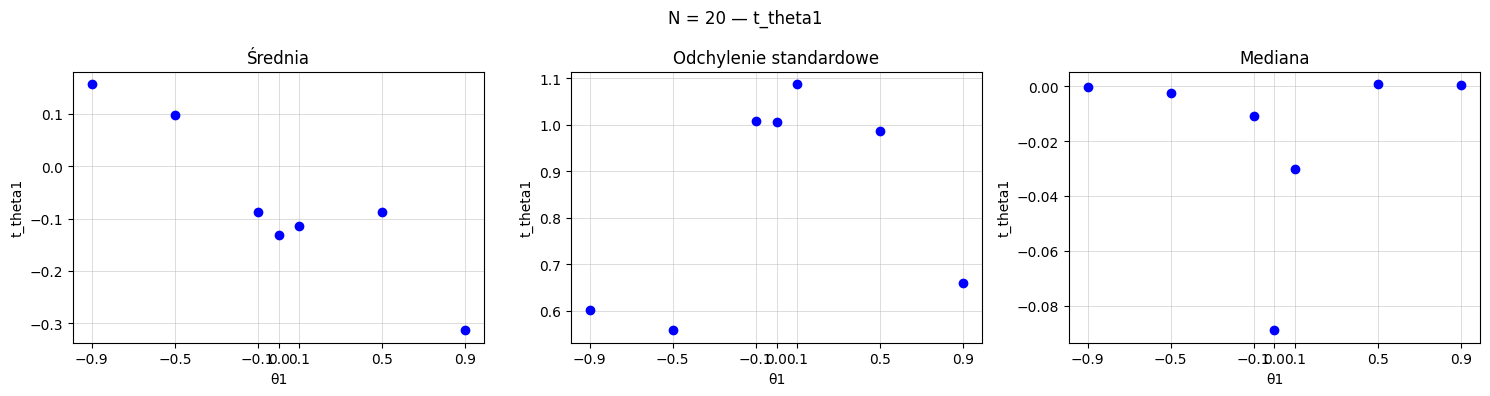

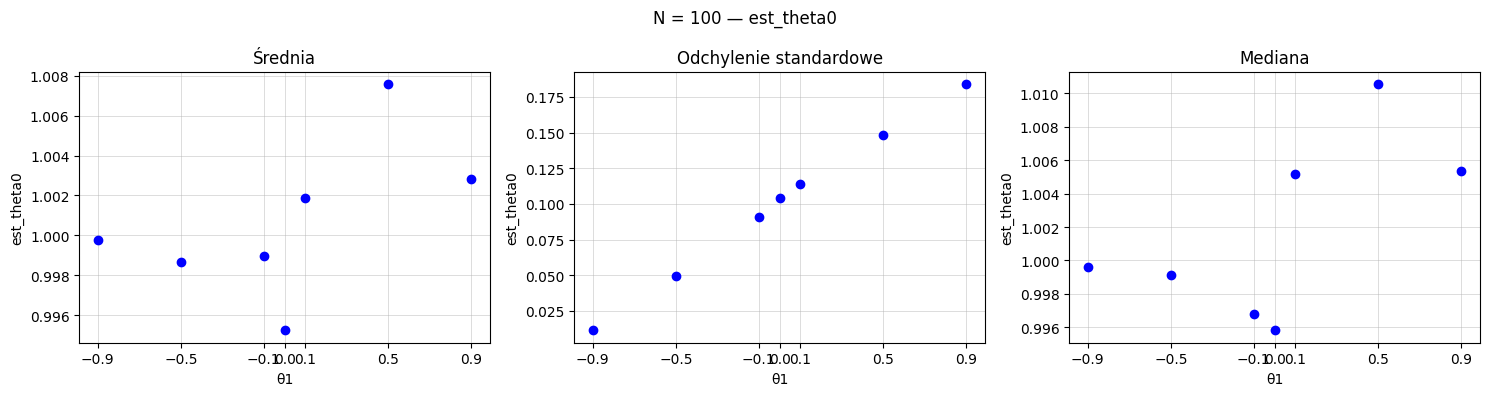

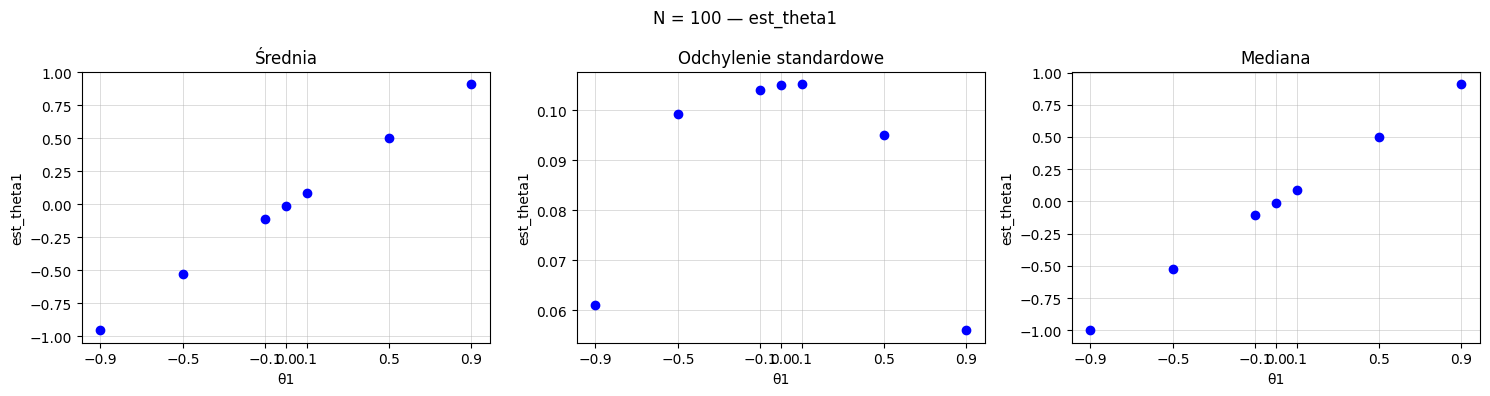

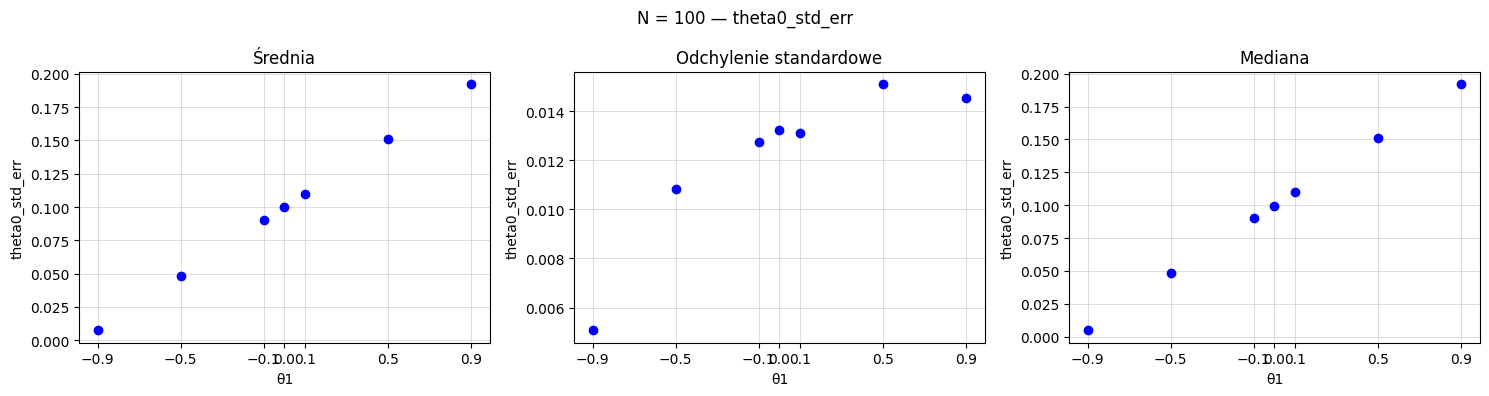

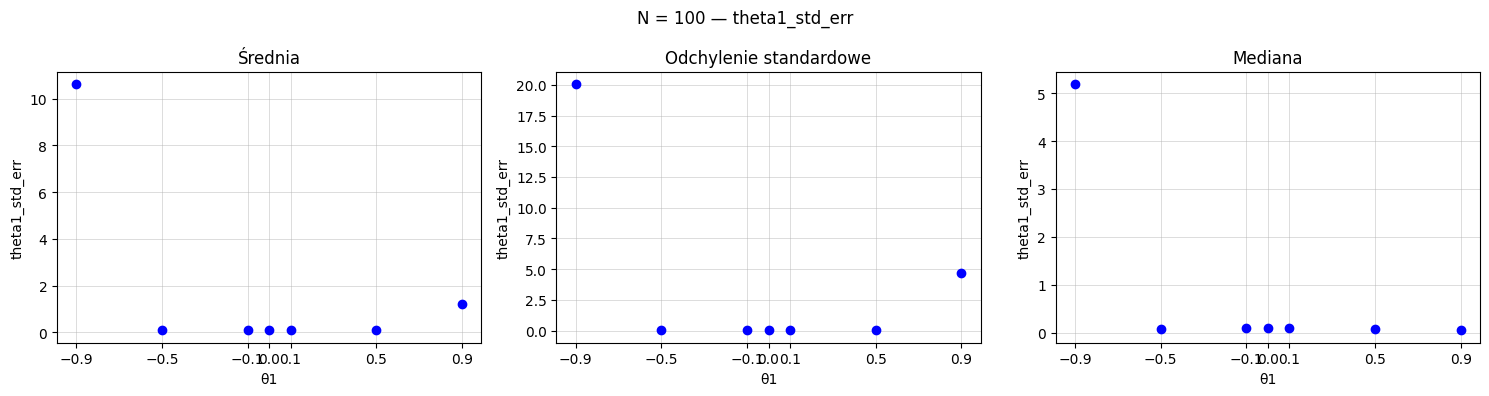

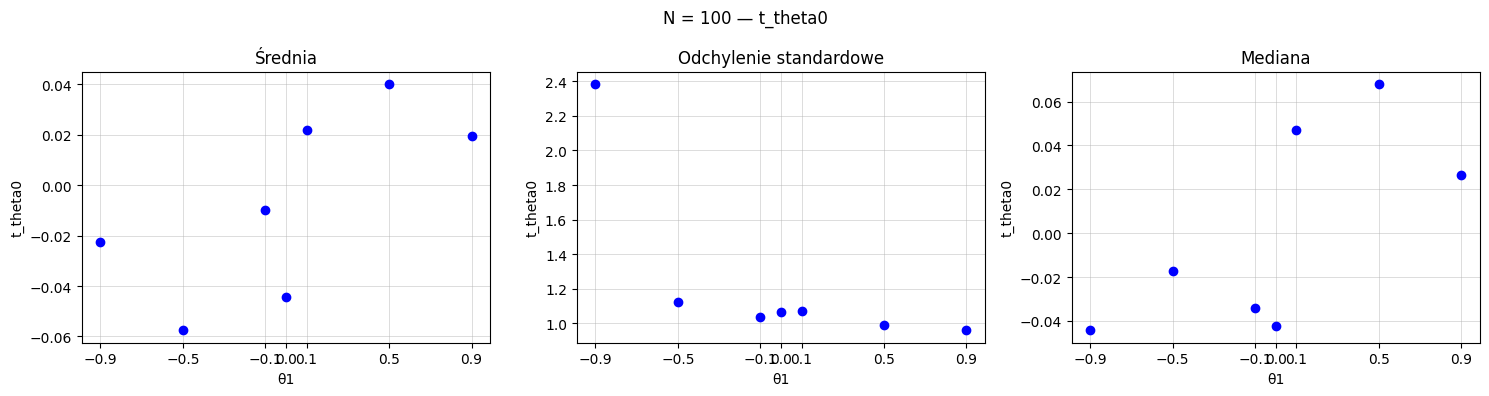

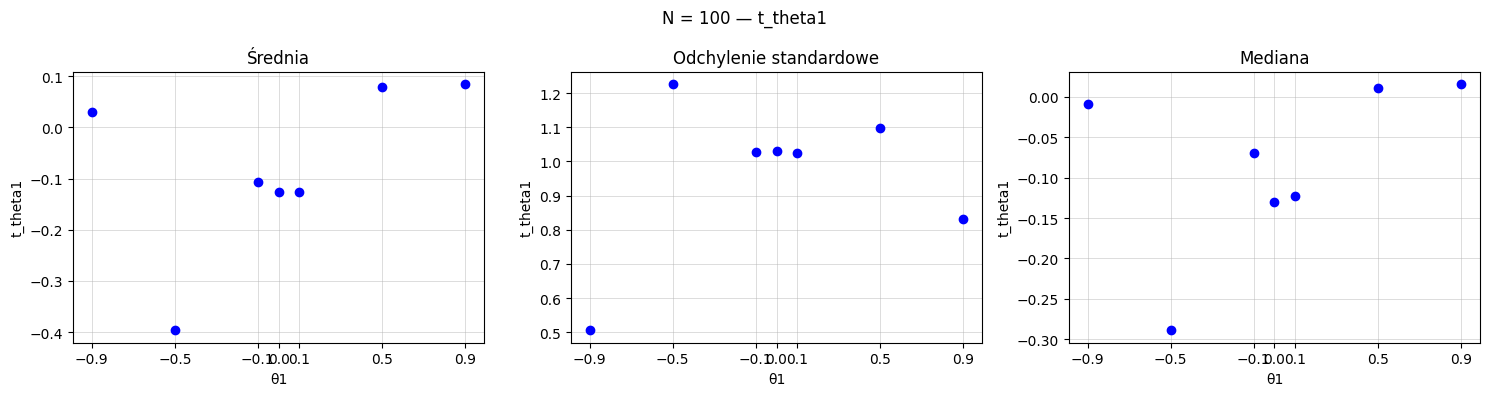

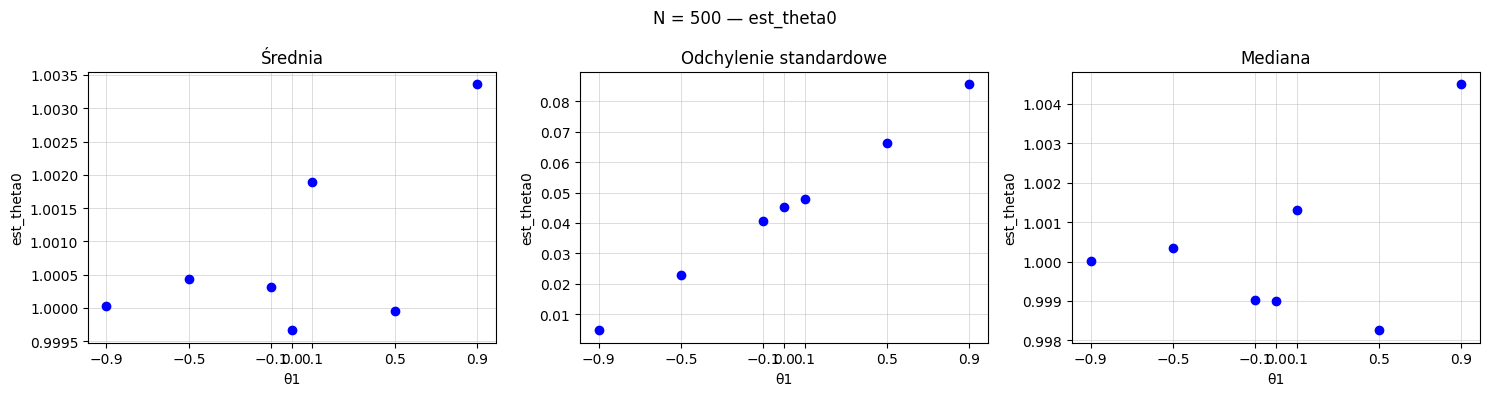

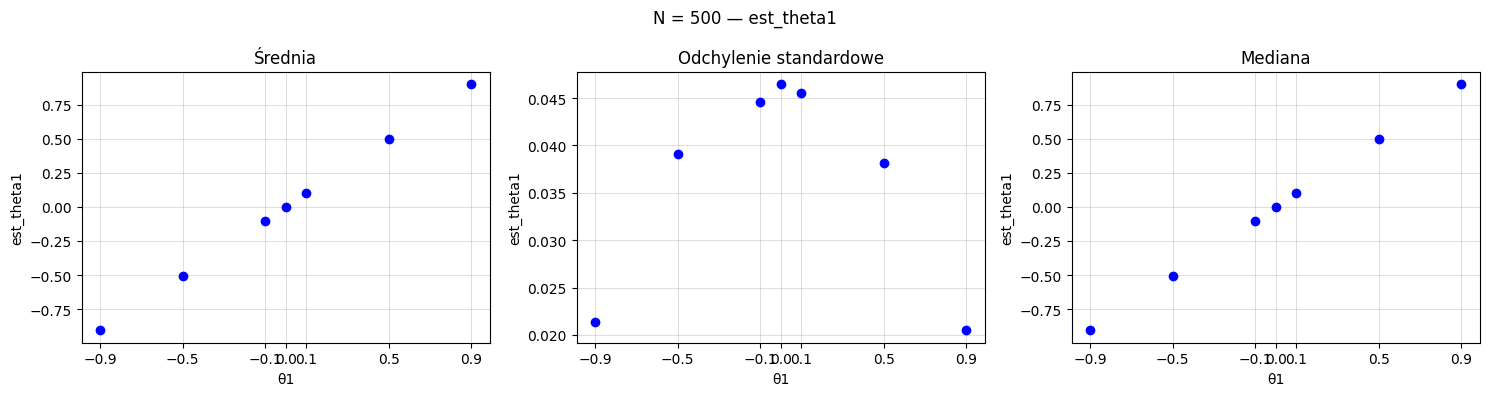

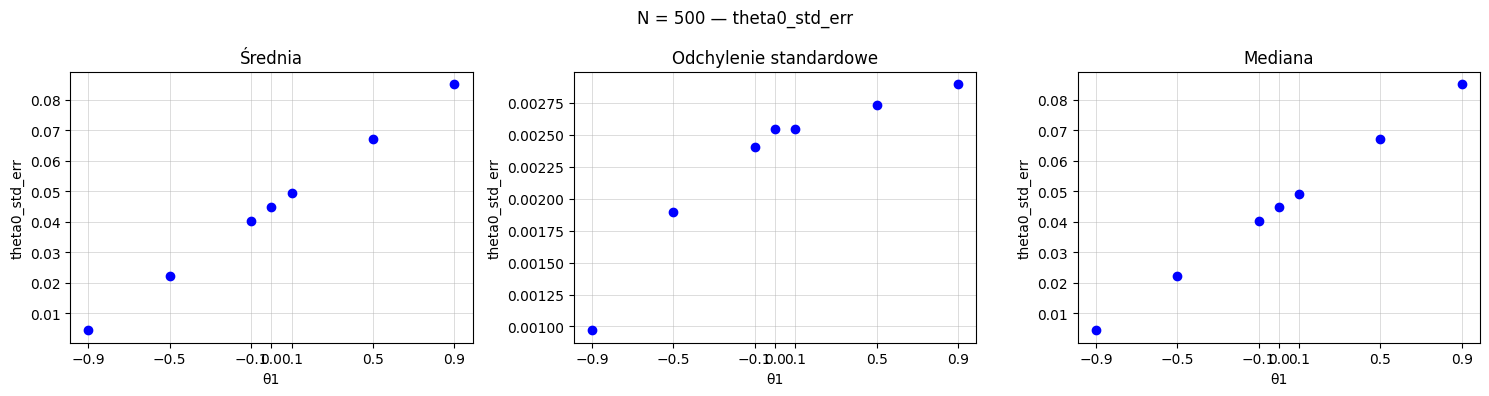

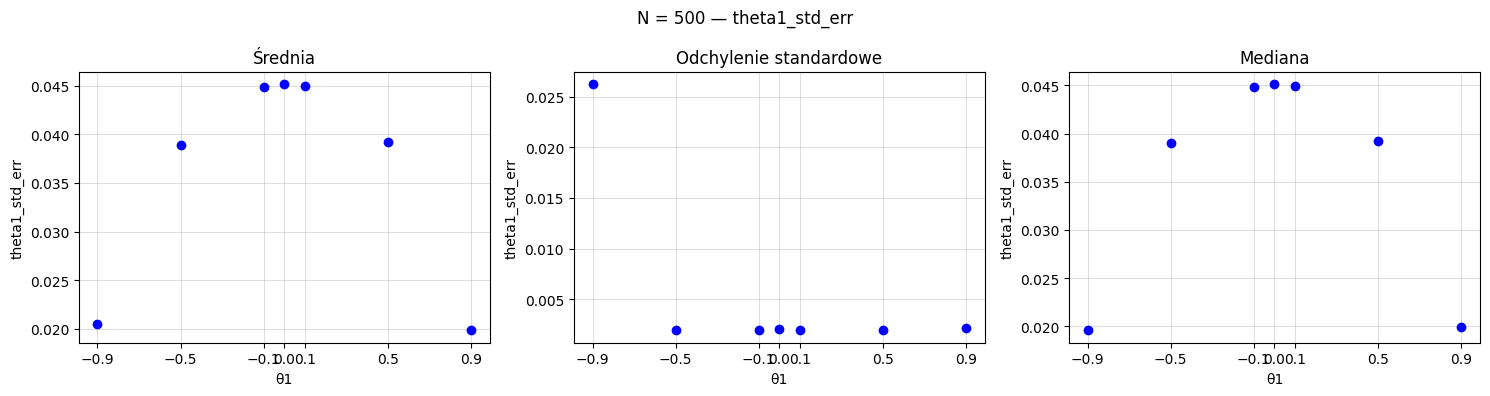

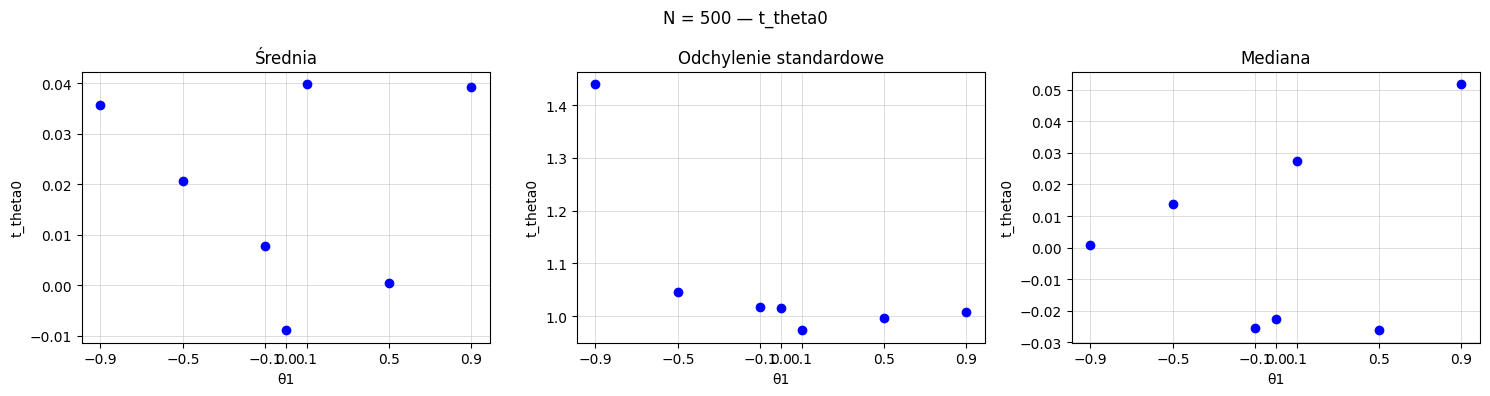

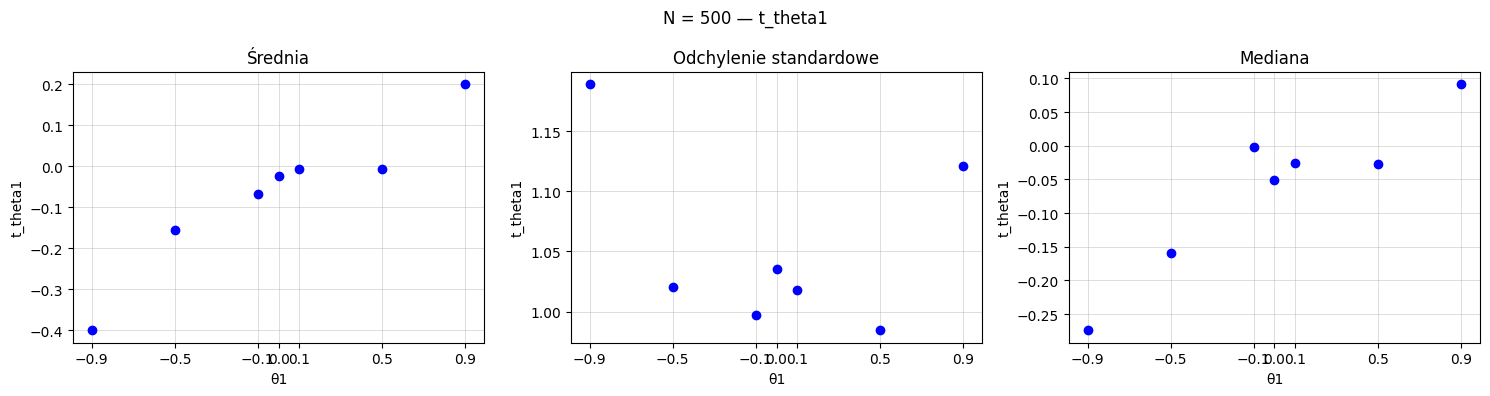

In [7]:
summary_columns = [
    "est_theta0",
    "est_theta1",
    "theta0_std_err",
    "theta1_std_err",
    "t_theta0",
    "t_theta1",
]
stat_map = {
    "mean": "Średnia",
    "std": "Odchylenie standardowe",
    "50%": "Mediana",
}


stats = []
for (theta1_value, sample_size), df in summaries.items():
    desc = df[summary_columns].describe()
    stats.append({
        "theta1": theta1_value,
        "N": sample_size,
        **{f"{stat}_{col}": desc.loc[stat, col] for stat in stat_map for col in summary_columns}
    })

results_df = pd.DataFrame.from_records(stats)

for sample_size in N:
    subset = results_df[results_df["N"] == sample_size].sort_values("theta1")
    x = subset["theta1"].values

    for col in summary_columns:
        fig, axes = plt.subplots(1, len(stat_map), figsize=(15, 4), sharex=True)
        if len(stat_map) == 1:
            axes = [axes]  # ensure iterable

        for ax, (stat, stat_label) in zip(axes, stat_map.items()):
            y = subset[f"{stat}_{col}"].values
            ax.plot(x, y, marker="o", linestyle="", color='blue')
            ax.set_title(stat_label)
            ax.set_xlabel("θ1")
            ax.set_ylabel(col)
            ax.grid(True, linewidth=0.5, alpha=0.6)
            ax.set_xticks(x)

        fig.suptitle(f"N = {sample_size} — {col}")
        plt.tight_layout()
        plt.show()

In [11]:
columns = ["est_theta0", "est_theta1", "theta0_std_err", "theta1_std_err", "t_theta0", "t_theta1"]

for (theta1_value, sample_size), summary_df in summaries.items():
    print(f"Normality tests for theta1 = {theta1_value}, N = {sample_size}")
    print("--" * 10)
    print("")

    for col in columns:
        test_data = summary_df[col]

        # Test Shapiro-Wilka
        shapiro_stat, shapiro_p = stats.shapiro(test_data)
        print(f"Shapiro-Wilk test for {col}: stat={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

        if shapiro_p > 0.05:
            print(f"{col} follows a normal distribution (fail to reject H0)")
        else:
            print(f"{col} does not follow a normal distribution (reject H0)")

        print("")

    print("--" * 10)
    print("\n\n")

Normality tests for theta1 = -0.9, N = 20
--------------------

Shapiro-Wilk test for est_theta0: stat=0.9986, p-value=0.6395
est_theta0 follows a normal distribution (fail to reject H0)

Shapiro-Wilk test for est_theta1: stat=0.3156, p-value=0.0000
est_theta1 does not follow a normal distribution (reject H0)

Shapiro-Wilk test for theta0_std_err: stat=0.5401, p-value=0.0000
theta0_std_err does not follow a normal distribution (reject H0)

Shapiro-Wilk test for theta1_std_err: stat=0.8349, p-value=0.0000
theta1_std_err does not follow a normal distribution (reject H0)

Shapiro-Wilk test for t_theta0: stat=0.9954, p-value=0.0042
t_theta0 does not follow a normal distribution (reject H0)

Shapiro-Wilk test for t_theta1: stat=0.2955, p-value=0.0000
t_theta1 does not follow a normal distribution (reject H0)

--------------------



Normality tests for theta1 = -0.9, N = 100
--------------------

Shapiro-Wilk test for est_theta0: stat=0.9980, p-value=0.2848
est_theta0 follows a normal distr

In [ ]:
#Wykres nie jest wywołany tutaj ze względu na ograniczenia sprzętowe. Na potrzeby projektu został on wywołany w Google Colab
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

columns = ["est_theta0", "est_theta1", "theta0_std_err", "theta1_std_err", "t_theta0", "t_theta1"]
theta1_values = [-0.9, -0.5, -0.1, 0, 0.1, 0.5, 0.9]
sample_sizes = [20, 100, 500]

# Nowa mapa kolorów dla konkretnych wartości θ₁
theta1_colors = {
    -0.9: "#001f7f",  # granatowy
    -0.5: "#0074D9",  # niebieski
    -0.1: "#7FDBFF",  # jasny niebieski
     0.0: "#2ECC40",  # zielony
     0.1: "#FFDC00",  # żółty
     0.5: "#FFB84D",  # jasny pomarańczowy
     0.9: "#FF851B",  # ciemny pomarańczowy
}

# Przygotowanie danych z wynikami testów
results = []
for (theta1_value, sample_size), summary_df in summaries.items():
    for col in columns:
        test_data = summary_df[col]
        shapiro_stat, shapiro_p = stats.shapiro(test_data)
        results.append({
            "N": sample_size,
            "theta1": theta1_value,
            "column": col,
            "p_value": shapiro_p
        })

results_df = pd.DataFrame(results)

# Styl i wygląd wykresów
sns.set(style="whitegrid", context="talk")

fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)

for i, N in enumerate(sample_sizes):
    ax = axes[i]
    subset = results_df[results_df["N"] == N]

    # Jitter — lekkie przesunięcie, żeby punkty się nie nakładały
    jitter_strength = 0.15
    x_positions = np.arange(len(columns))

    for theta1_value in theta1_values:
        sub_theta = subset[subset["theta1"] == theta1_value]
        x_jittered = sub_theta["column"].map({col: j for j, col in enumerate(columns)}).astype(float) \
                     + np.random.uniform(-jitter_strength, jitter_strength, size=len(sub_theta))

        ax.scatter(
            x_jittered,
            sub_theta["p_value"],
            color=theta1_colors[theta1_value],
            s=80,
            edgecolor="k",
            alpha=0.9,
            label=f"θ₁ = {theta1_value}" if i == 0 else None  # legenda tylko raz
        )

    # Linia istotności
    ax.axhline(0.05, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

    # Ustawienia osi
    ax.set_title(f"N = {N}", fontsize=18, fontweight='bold')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(columns, rotation=30, ha='right')
    ax.set_ylim(-0.1, 1.05)
    ax.grid(True, linestyle='--', alpha=0.6)
    if i == 0:
        ax.set_ylabel("p-value")

# Legenda po prawej stronie, poza wykresami
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels
    ,
    title="Wartości θ₁",
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=12,
    title_fontsize=13
)

plt.suptitle("Wartości p-value testu Shapiro–Wilka dla parametrów MA(1)", fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.95, 0.96])  # zostawiamy miejsce na legendę
plt.show()

/tmp/ipython-input-1429158869.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", max(len(theta1), 1))


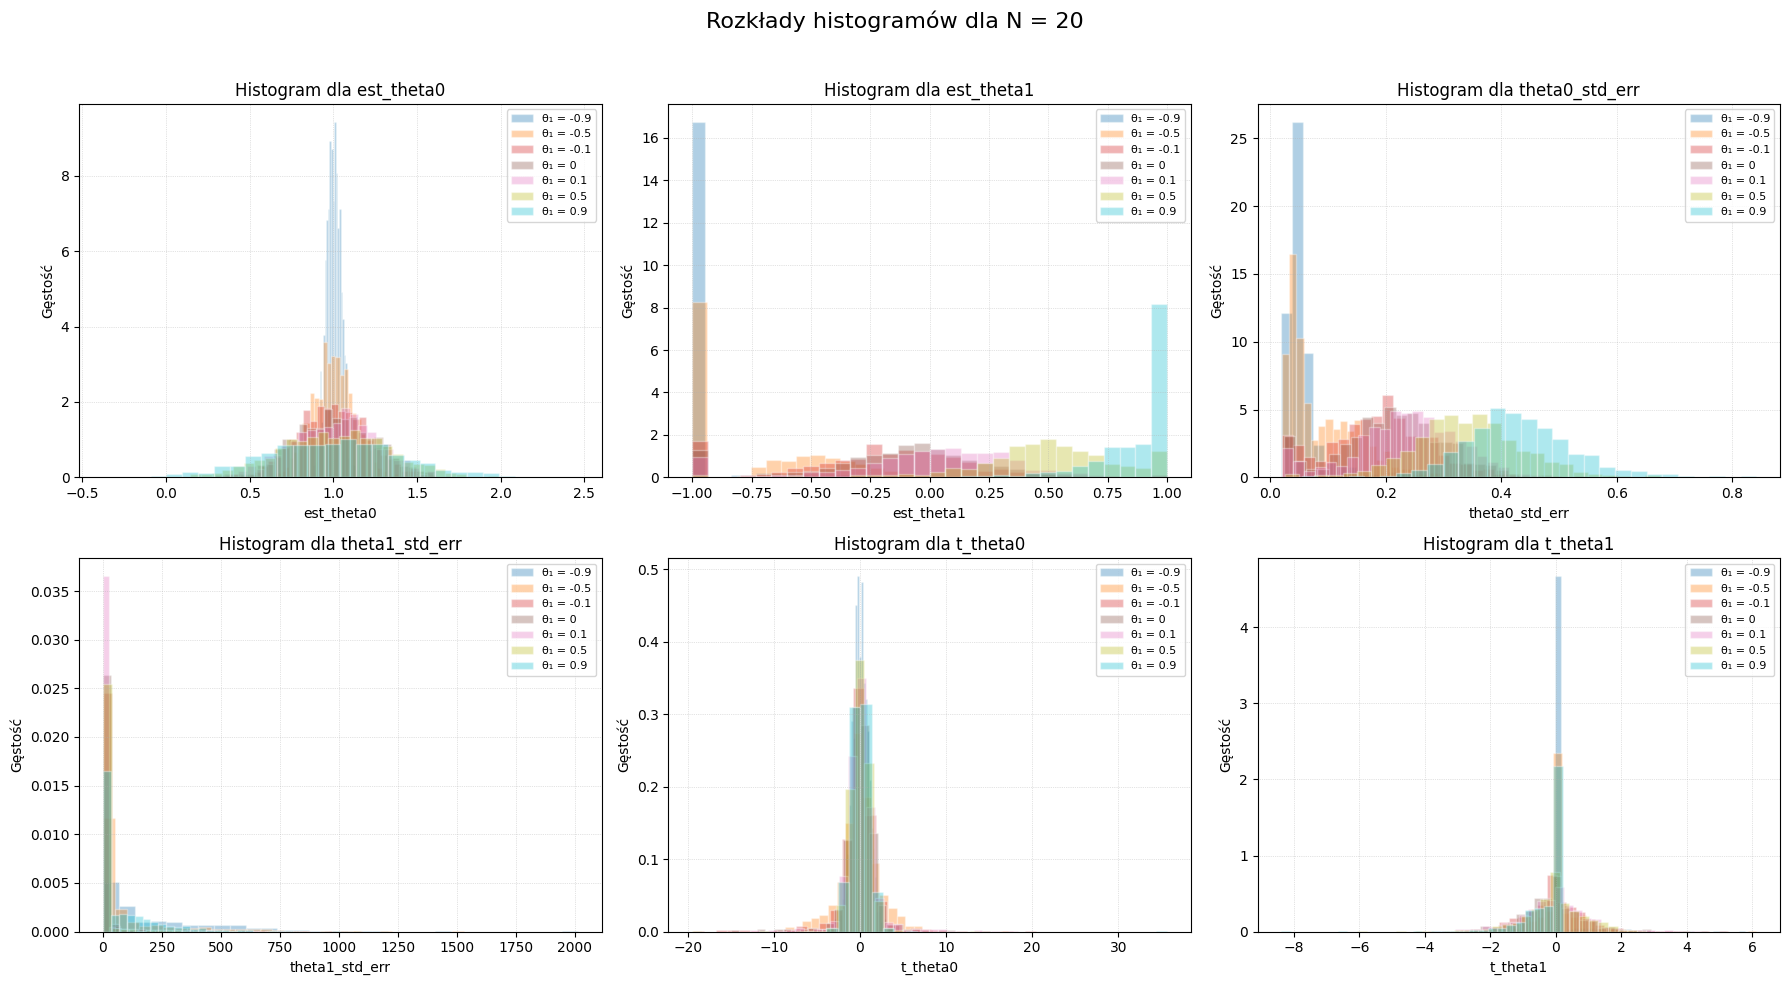

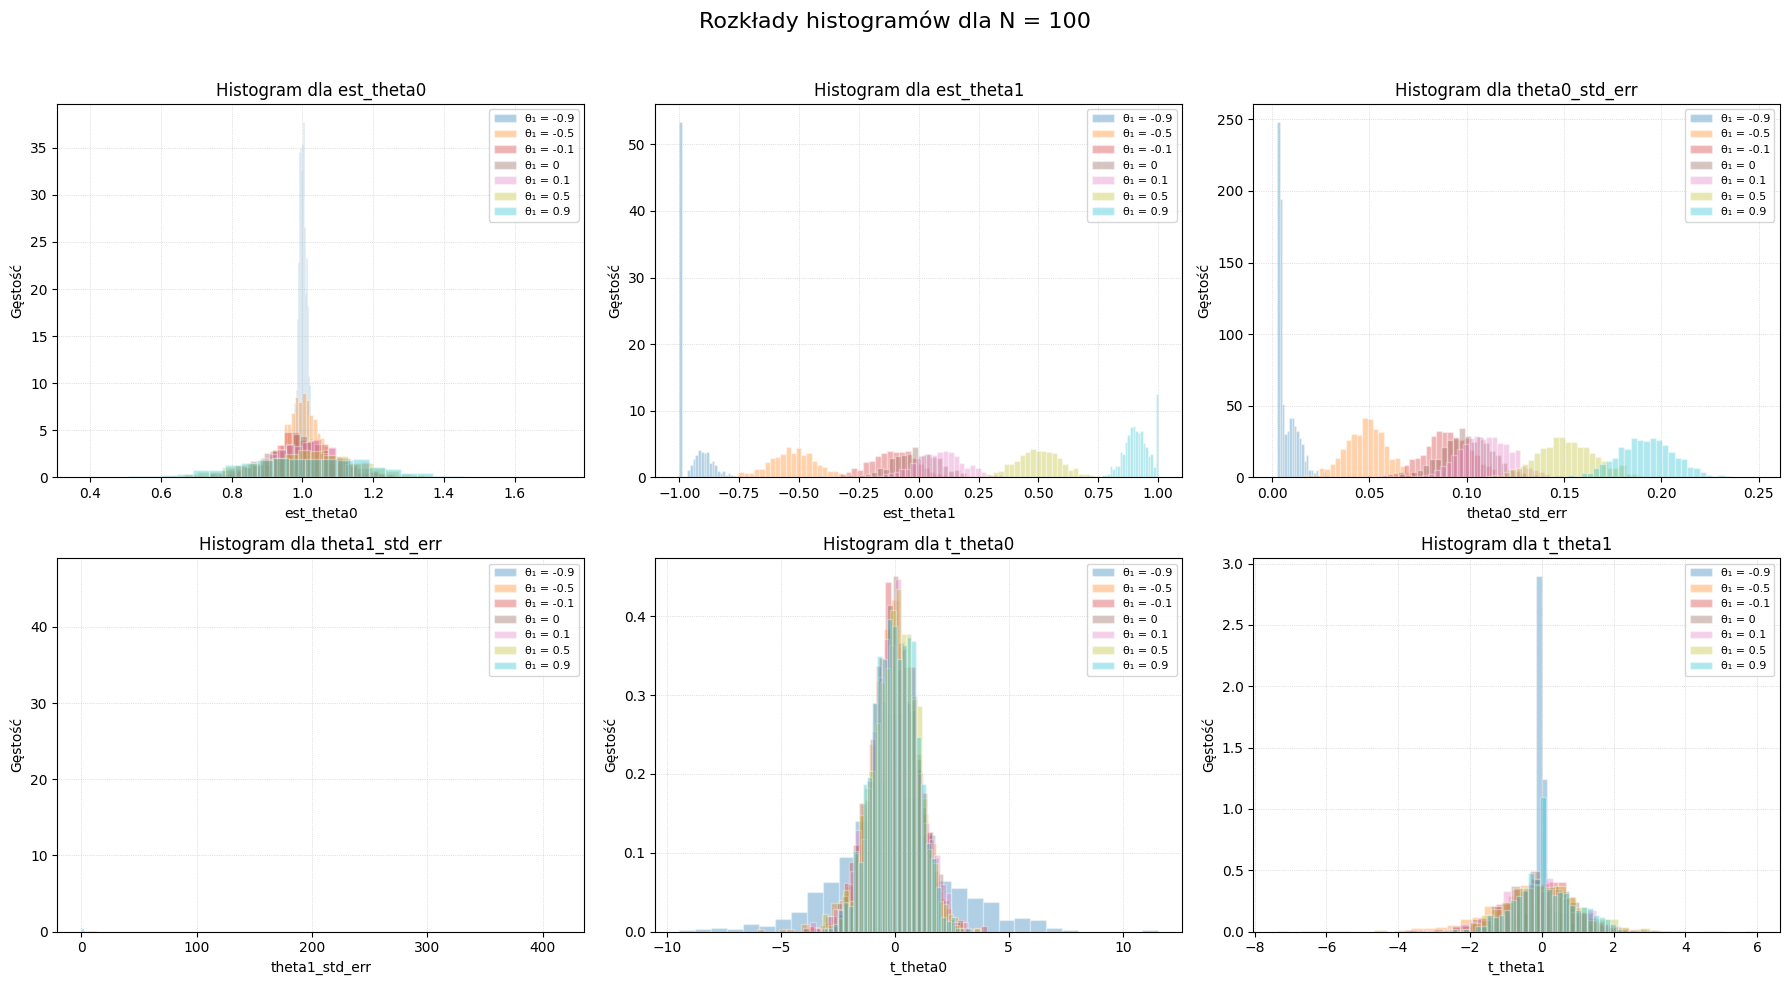

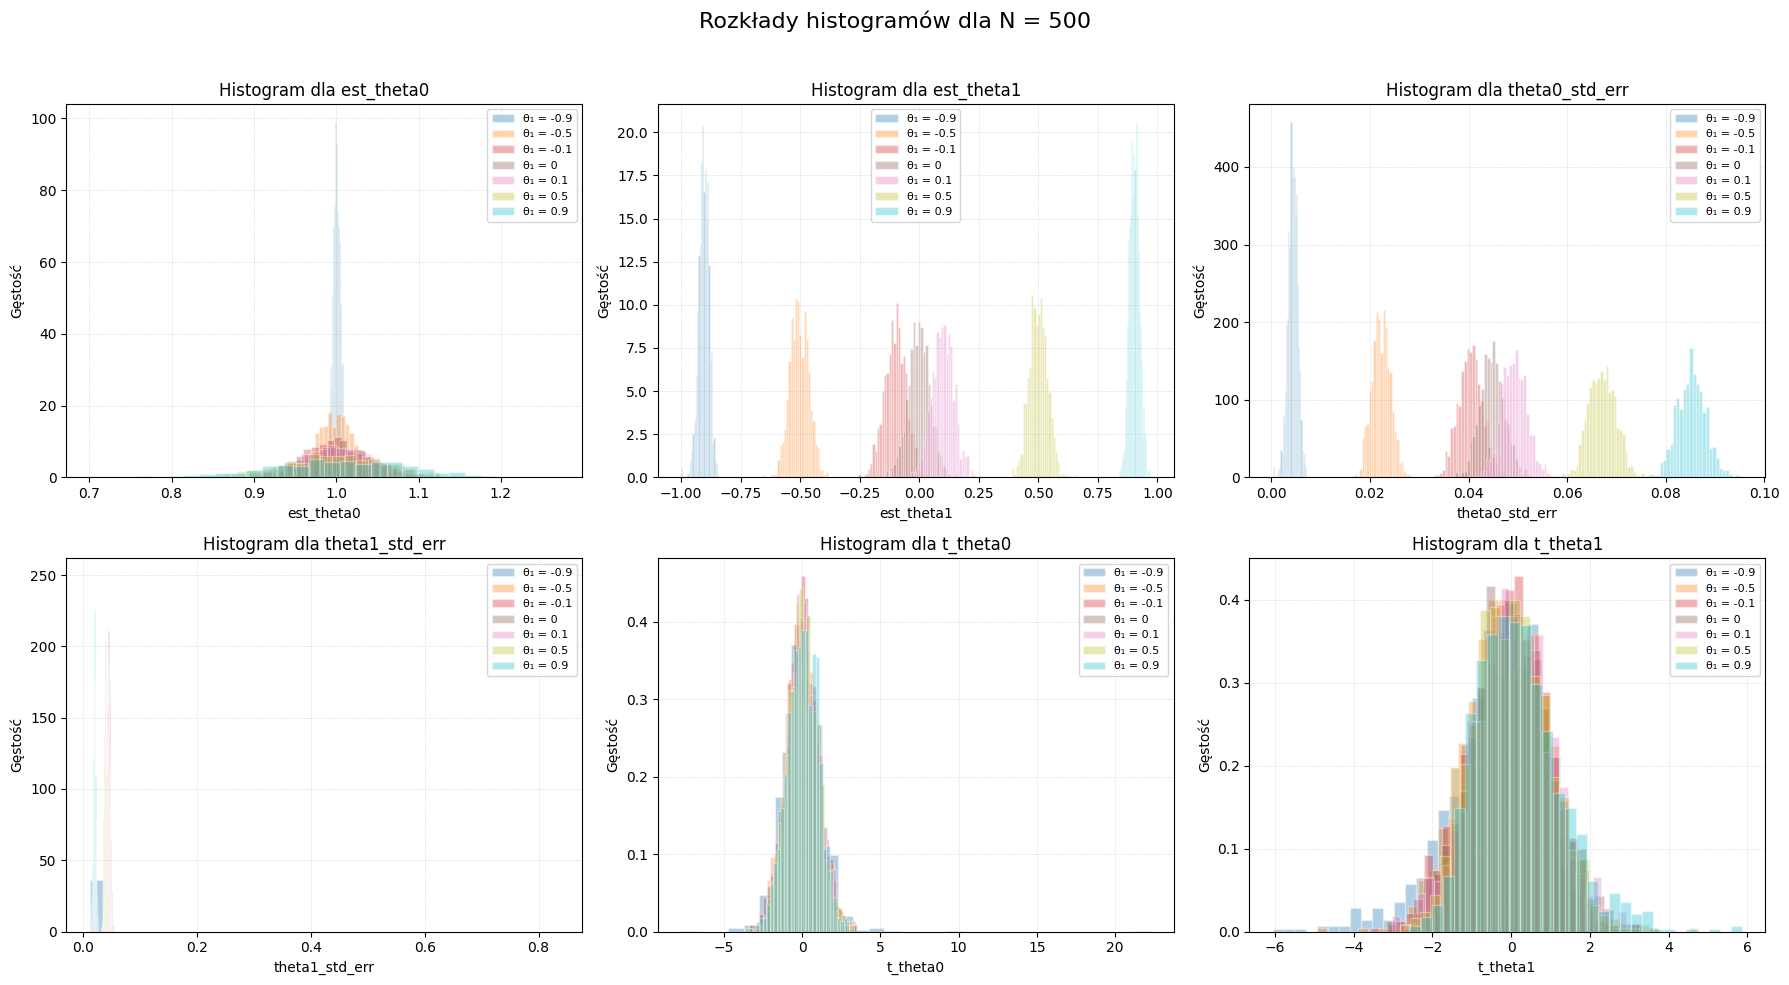

In [12]:
theta_labels = [f"θ₁ = {value:g}" for value in theta1]
color_map = plt.cm.get_cmap("tab10", max(len(theta1), 1))
fig_rows, fig_cols = 2, 3

for sample_size in N:
    fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(18, 10), sharex=False, sharey=False)
    axes = axes.flatten()

    for ax, col in zip(axes, columns):
        for idx, theta1_value in enumerate(theta1):
            data = summaries[(theta1_value, sample_size)][col].dropna().to_numpy()

            if data.size == 0:
                continue

            ax.hist(
                data,
                bins=30,
                color=color_map(idx),
                alpha=0.35,
                edgecolor="white",
                density=True,
                label=theta_labels[idx],
            )

        ax.set_title(f"Histogram dla {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Gęstość")
        ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.7)

        handles, labels = ax.get_legend_handles_labels()
        if handles:
            unique = dict(zip(labels, handles))
            ax.legend(unique.values(), unique.keys(), fontsize=8, loc="best")

    for ax in axes[len(columns):]:
        ax.axis("off")

    fig.suptitle(f"Rozkłady histogramów dla N = {sample_size}", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

/tmp/ipython-input-1781795495.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=labels, showmeans=True)
/tmp/ipython-input-1781795495.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=labels, showmeans=True)
/tmp/ipython-input-1781795495.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=labels, showmeans=True)
/tmp/ipython-input-1781795495.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(b

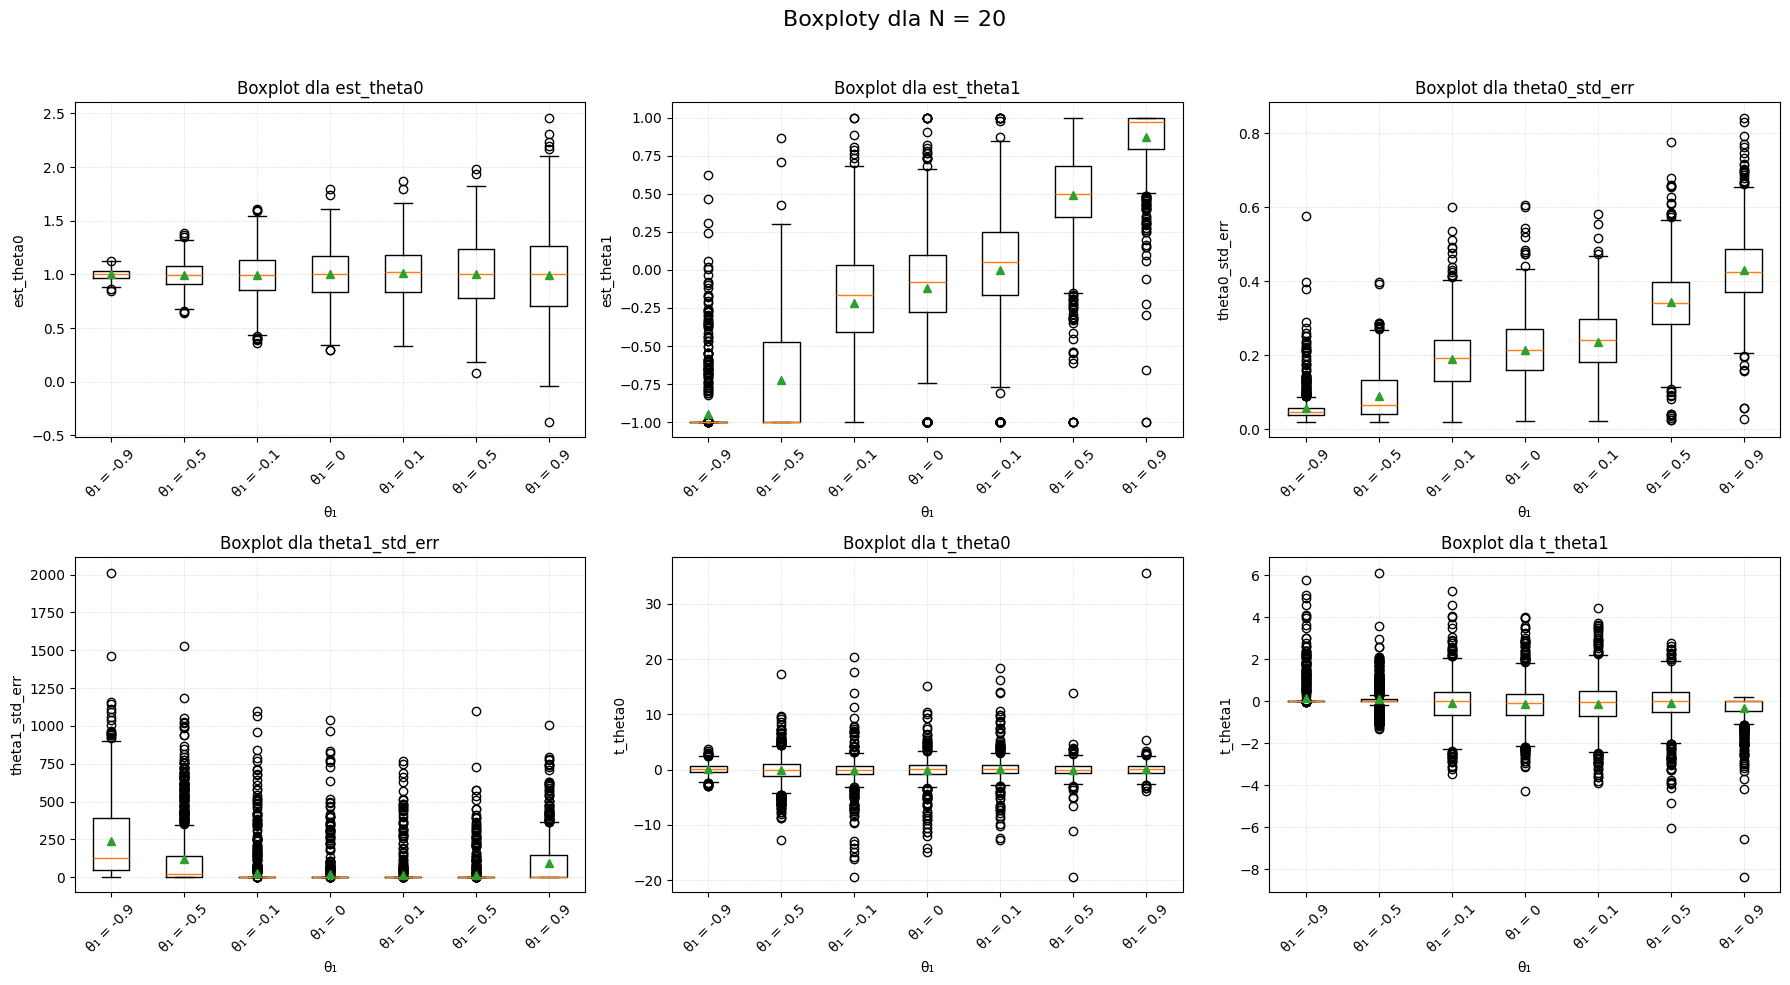

/tmp/ipython-input-1781795495.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=labels, showmeans=True)
/tmp/ipython-input-1781795495.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=labels, showmeans=True)
/tmp/ipython-input-1781795495.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=labels, showmeans=True)
/tmp/ipython-input-1781795495.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(b

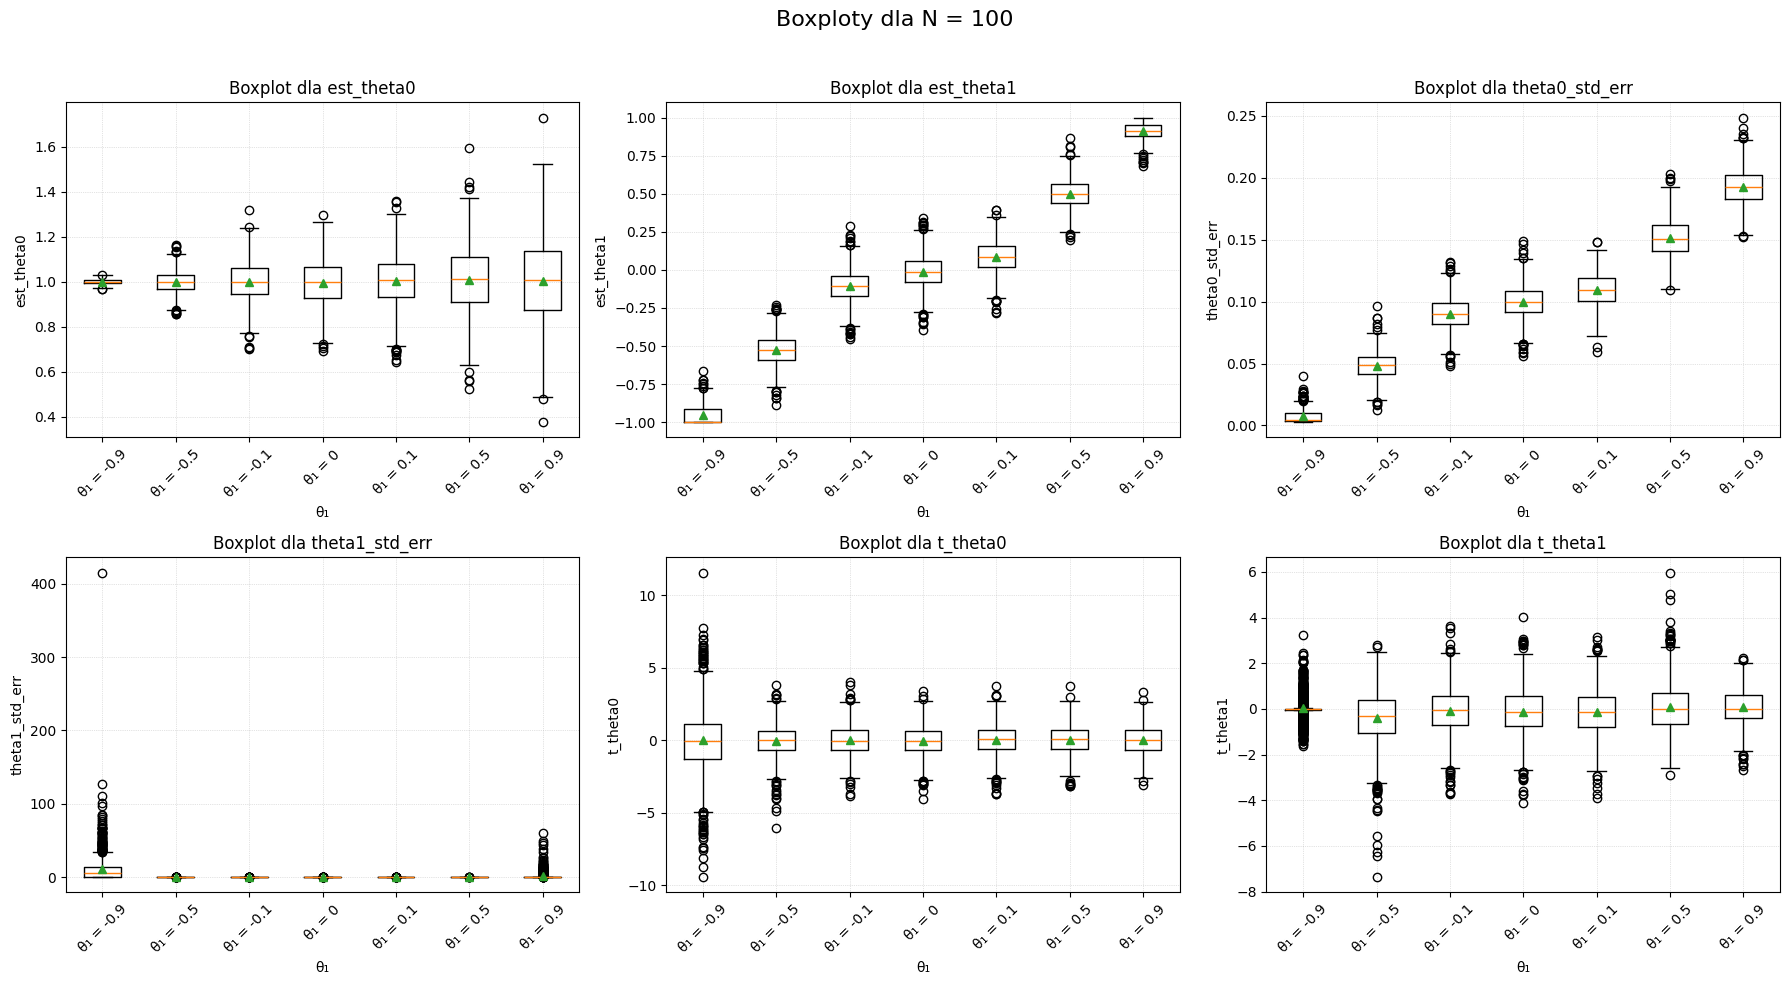

/tmp/ipython-input-1781795495.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=labels, showmeans=True)
/tmp/ipython-input-1781795495.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=labels, showmeans=True)
/tmp/ipython-input-1781795495.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=labels, showmeans=True)
/tmp/ipython-input-1781795495.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(b

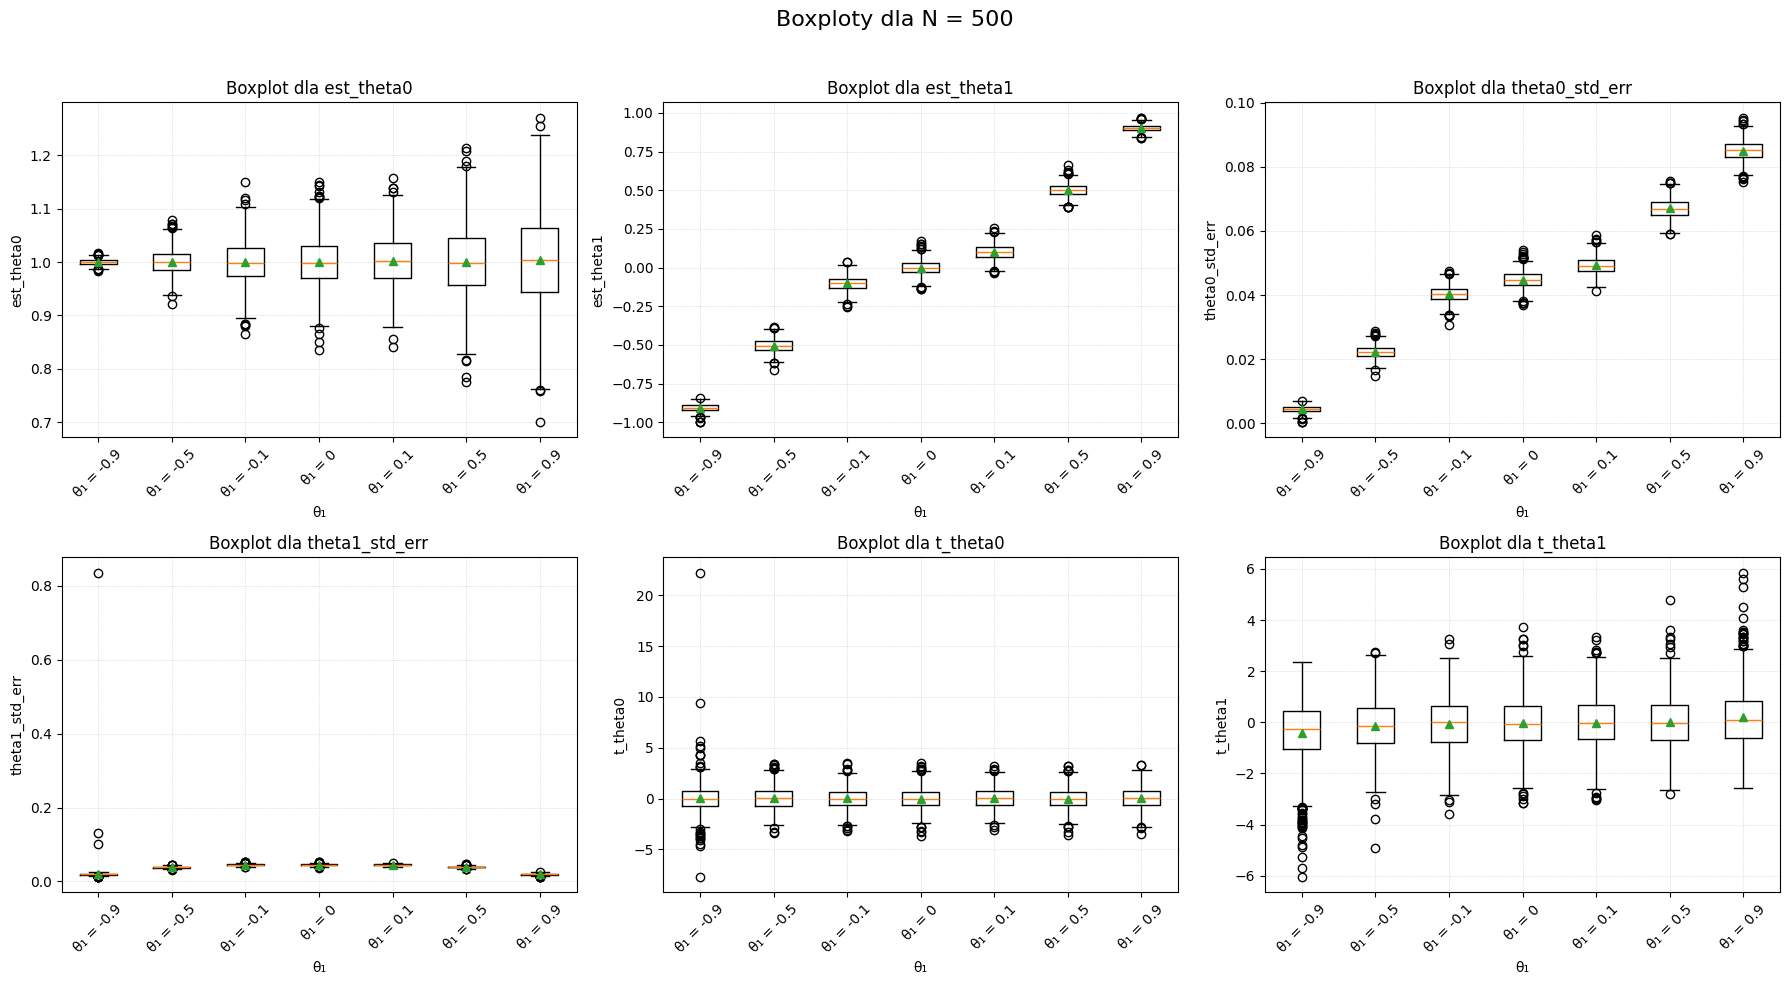

In [13]:
fig_rows, fig_cols = 2, 3

for sample_size in N:
    fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(18, 10), sharey=False)
    axes = axes.flatten()

    for ax, col in zip(axes, columns):
        box_data = []
        labels = []

        for theta1_value in theta1:
            values = summaries[(theta1_value, sample_size)][col].dropna().to_numpy()

            if values.size == 0:
                continue

            box_data.append(values)
            labels.append(f"θ₁ = {theta1_value:g}")

        if not box_data:
            ax.text(0.5, 0.5, "Brak danych", transform=ax.transAxes, ha="center", va="center")
            ax.axis("off")
            continue

        ax.boxplot(box_data, labels=labels, showmeans=True)
        ax.set_title(f"Boxplot dla {col}")
        ax.set_xlabel("θ₁")
        ax.set_ylabel(col)
        ax.tick_params(axis="x", rotation=45)
        ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.7)

    for ax in axes[len(columns):]:
        ax.axis("off")

    fig.suptitle(f"Boxploty dla N = {sample_size}", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()